<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 02</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Data cleaning</div><div style="font-size:1.05em;opacity:0.85">Every row we drop, and why.</div></div>

Stage 01 asked *is this the file we think it is?*; this stage asks *which of its rows describe
a customer buying a product?* Everything else — guest checkouts, postage, accounting entries,
export duplicates — has to go, and each removal has a cost that should be visible.

**Pipeline rule.** The rules are not written here. They live in
`churnvalue.data.clean.CLEANING_RULES`, applied in a fixed order by both `clean_transactions`
(the pipeline) and `cleaning_audit` (this notebook), so the audit can never drift from what the
pipeline actually does. This notebook measures each rule and argues for it.

| | |
|---|---|
| **Input** | `data/interim/raw.parquet` (stage 01) · `data/interim/transactions.parquet` (from `churnvalue build-snapshots`) |
| **Outputs** | `reports/results/02_summary.json` · `reports/figures/02_*.png` |
| **Parameters** | none — the rules are code, reviewed and tested (`tests/test_clean.py`) |
| **Shared code** | `churnvalue.data.clean` (rules, audit, pandera schema) · `churnvalue.data.download` · `churnvalue.viz.style` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C1 rule by rule</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C2 duplicates</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C3 missing customers</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C4 non-products</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C5 returns</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">C6 final table</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from churnvalue.config import load_config, project_root
from churnvalue.data.clean import (
    CLEANING_RULES,
    PRODUCT_CODE_PATTERN,
    TRANSACTIONS_SCHEMA,
    apply_rules,
    clean_transactions,
    cleaning_audit,
    same_day_reversals,
)
from churnvalue.data.download import label_sheets, raw_sheet_rows
from churnvalue.reporting import StageSummary
from churnvalue.viz import style
from churnvalue.viz.style import INK, MUTED, NEUTRAL, RETAINED

os.chdir(project_root())
CFG = load_config()
STAGE, FIGURES, RESULTS = "02", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


RAW = CFG.data.interim_dir / "raw.parquet"
raw = pd.read_parquet(RAW)
raw_revenue = (raw["Quantity"] * raw["Price"]).sum()
S["raw_rows"] = len(raw)
S["raw_revenue"] = raw_revenue

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C1 · Rule by rule</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">rows and revenue removed, in application order</span></div>

Order matters for attribution: a line that fails two rules is charged to the first. The rules
run cheapest-to-justify first (duplicates, then lines with no customer) so that the later,
more debatable rules are measured on the rows that could actually reach the model.

In [2]:
audit = cleaning_audit(raw)
S["audit"] = audit.set_index("rule")[["rows_removed", "rows_remaining", "revenue_removed"]].to_dict(
    orient="index"
)
display(
    audit.style.format(
        {"rows_removed": "{:,}", "rows_remaining": "{:,}", "revenue_removed": "£{:,.0f}"}
    ).hide(axis="index")
)

rule,reason,rows_removed,rows_remaining,revenue_removed
exact_duplicates,identical invoice lines repeated in the export,"34,335","1,033,036","£431,717"
missing_customer_id,guest checkouts cannot be followed over time,"235,151","797,885","£2,565,542"
non_positive_price,"free samples, adjustments and data-entry errors",70,"797,815",£0
zero_quantity,lines that move no goods,0,"797,815",£0
bad_debt_adjustment,accounting entries (invoices prefixed A),0,"797,815",£0
non_product_code,"postage, fees, manual lines, vouchers (stock codes not starting with 5 digits)","3,652","794,163","£-68,623"
inconsistent_return,C-invoices with positive quantity or sales with negative quantity,0,"794,163",£0
same_day_reversal,"an order cancelled the same day for the same product, price and quantity (mis-keys)","3,142","791,021",£0


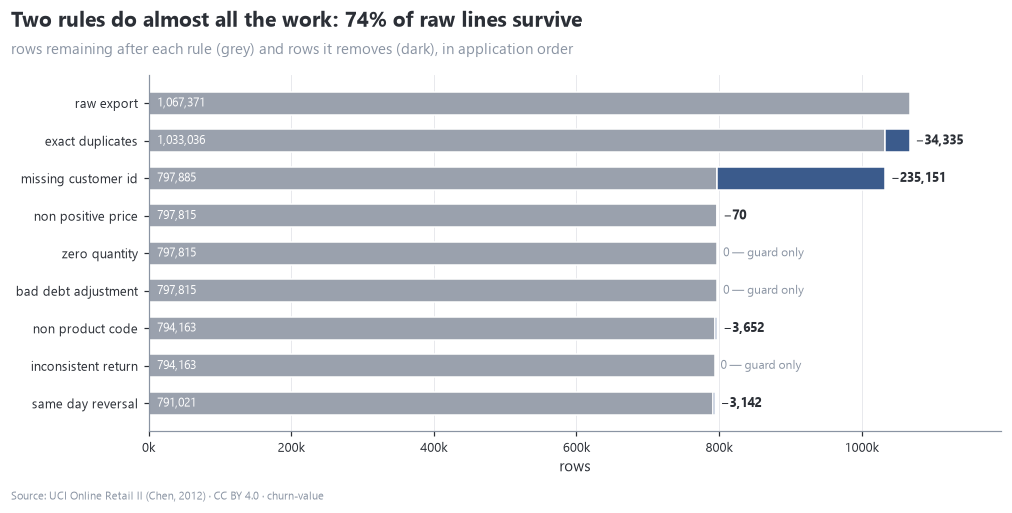

In [3]:
steps = pd.concat(
    [pd.DataFrame({"rule": ["raw export"], "rows_remaining": [len(raw)]}), audit], ignore_index=True
)
fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(steps))[::-1]
ax.barh(y, steps["rows_remaining"], color=RETAINED, height=0.62, edgecolor="white")
for yi, (_, row) in zip(y, steps.iterrows(), strict=True):
    removed = row.get("rows_removed", np.nan)
    if pd.notna(removed) and removed > 0:
        ax.barh(
            yi, removed, left=row["rows_remaining"], color=NEUTRAL, height=0.62, edgecolor="white"
        )
        ax.text(
            row["rows_remaining"] + removed + 8_000,
            yi,
            f"−{removed:,.0f}",
            va="center",
            fontsize=8.5,
            color=INK,
            fontweight="bold",
        )
    elif pd.notna(removed):
        ax.text(
            row["rows_remaining"] + 8_000,
            yi,
            "0 — guard only",
            va="center",
            fontsize=8,
            color=MUTED,
        )
    ax.text(12_000, yi, f"{row['rows_remaining']:,}", va="center", fontsize=8, color="white")
ax.set_yticks(y, steps["rule"].str.replace("_", " "))
ax.set_xlim(0, len(raw) * 1.12)
ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1e3:.0f}k")
ax.grid(axis="y", visible=False)
ax.set_xlabel("rows")
S["rows_kept_share"] = audit["rows_remaining"].iloc[-1] / len(raw)
style.headline(
    fig,
    f"Two rules do almost all the work: {S['rows_kept_share']:.0%} of raw lines survive",
    "rows remaining after each rule (grey) and rows it removes (dark), in application order",
)
style.add_source(fig)
save(fig, "rules")
plt.show()

Three rules remove nothing on this file (`zero_quantity`, `bad_debt_adjustment`,
`inconsistent_return`): the lines they target have already gone with the missing-customer
rule. They stay in the list as **guards** — cheap insurance if a future export changes.

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C2 · Duplicates</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">an export artefact, mostly</span></div>

Stage 01 found that 1–9 December 2010 is exported in both sheets. That overlap explains most of
the exact duplicates; the rest are identical lines inside one sheet — the same product, quantity,
price and timestamp on the same invoice. Those could in principle be two genuine scans, but an
identical timestamp to the second makes an export repeat far more likely, and they are dropped
for the same reason.

In [4]:
raw["sheet"] = label_sheets(len(raw), raw_sheet_rows(RAW))
columns = [c for c in raw.columns if c != "sheet"]
first_sheet, second_sheet = raw_sheet_rows(RAW)
cross = pd.merge(
    raw.loc[raw["sheet"] == first_sheet, columns].drop_duplicates(),
    raw.loc[raw["sheet"] == second_sheet, columns].drop_duplicates(),
    how="inner",
)
within = raw.groupby("sheet")[columns].apply(lambda g: g.duplicated().sum())
duplicates = pd.Series(
    {
        "same line in both sheets (Dec 2010 overlap)": len(cross),
        "repeated inside one sheet": int(within.sum()),
    }
)
S["duplicates_cross_sheet"] = len(cross)
S["duplicates_within_sheet"] = int(within.sum())
S["duplicates_total"] = int(raw[columns].duplicated().sum())
assert S["duplicates_cross_sheet"] + S["duplicates_within_sheet"] == S["duplicates_total"]
display(duplicates.rename("lines").to_frame().style.format("{:,}"))

,lines
same line in both sheets (Dec 2010 overlap),"22,202"
repeated inside one sheet,"12,133"


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C3 · Missing customers</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">is it random?</span></div>

A line without `Customer ID` cannot be followed over time, so it can never enter a churn label —
dropping it is forced. The question that matters is whether it is *random*. If guest checkouts
were concentrated in one market or one period, the customers we keep would be a biased sample of
the business, and the conclusions would not transfer.

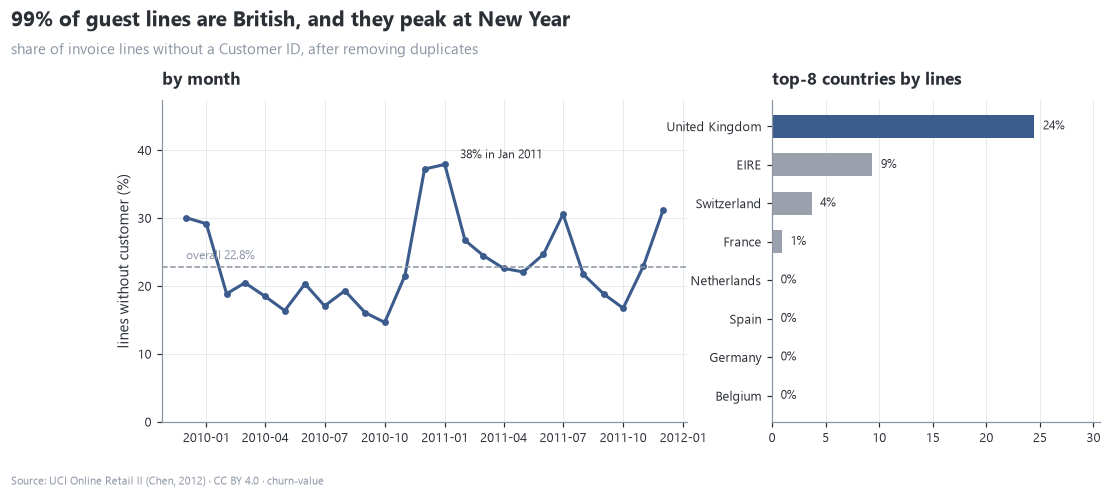

In [5]:
after_dupes = raw.loc[~raw[columns].duplicated()].copy()
after_dupes["missing_id"] = after_dupes["Customer ID"].isna()
after_dupes["revenue"] = after_dupes["Quantity"] * after_dupes["Price"]
after_dupes["month"] = after_dupes["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

by_month = after_dupes.groupby("month")["missing_id"].mean()
top = after_dupes["Country"].value_counts().head(8).index
by_country = after_dupes[after_dupes["Country"].isin(top)].groupby("Country")["missing_id"].mean()
by_country = by_country.sort_values()
line_value = after_dupes[after_dupes["revenue"] > 0].groupby("missing_id")["revenue"].median()

S["missing_share"] = after_dupes["missing_id"].mean()
S["missing_share_by_month_range"] = [by_month.min(), by_month.max()]
S["missing_revenue_share"] = (
    after_dupes.loc[after_dupes["missing_id"], "revenue"].sum() / after_dupes["revenue"].sum()
)
S["median_line_value"] = {"with_id": line_value[False], "missing_id": line_value[True]}
S["missing_share_uk"] = by_country.get("United Kingdom")
is_uk = after_dupes["Country"] == "United Kingdom"
S["uk_share_of_missing_lines"] = is_uk[after_dupes["missing_id"]].mean()
S["uk_share_of_all_lines"] = is_uk.mean()
S["missing_share_outside_uk"] = after_dupes.loc[~is_uk, "missing_id"].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.plot(by_month.index, by_month * 100, color=NEUTRAL, marker="o", markersize=3.5)
ax1.axhline(S["missing_share"] * 100, color=MUTED, lw=1, ls="--")
ax1.text(
    by_month.index[0],
    S["missing_share"] * 100 + 1.2,
    f"overall {S['missing_share']:.1%}",
    fontsize=8,
    color=MUTED,
)
ax1.set_ylabel("lines without customer (%)")
ax1.set_ylim(0, by_month.max() * 100 * 1.25)
ax1.set_title("by month")
colors = [NEUTRAL if c == "United Kingdom" else RETAINED for c in by_country.index]
ax2.barh(by_country.index, by_country * 100, color=colors, height=0.6)
for c, v in by_country.items():
    ax2.text(v * 100 + 0.8, c, f"{v:.0%}", va="center", fontsize=8, color=INK)
ax2.set_title("top-8 countries by lines")
ax2.grid(axis="y", visible=False)
ax2.set_xlim(0, by_country.max() * 100 * 1.25)
peak = by_month.idxmax()
ax1.annotate(
    f"{by_month.max():.0%} in {peak:%b %Y}",
    xy=(peak, by_month.max() * 100),
    xytext=(10, 4),
    textcoords="offset points",
    fontsize=8,
    color=INK,
)
style.headline(
    fig,
    f"{S['uk_share_of_missing_lines']:.0%} of guest lines are British, and they peak at New Year",
    "share of invoice lines without a Customer ID, after removing duplicates",
)
style.add_source(fig)
save(fig, "missing_customer")
plt.show()

The missing IDs are **not random**, in two ways:

- **by market** — 98.7 % of guest lines are British (the UK is 91.8 % of all lines); outside the
  UK only 3.5 % of lines lack an ID, against 24.5 % inside it. Export customers almost always
  buy through an account;
- **by time** — the share swings between 15 % and 38 % by month and peaks around New Year.

Guest lines are also small: a median of £5.02 against £12.48 for account lines, and 13.6 % of
revenue. That is consistent with occasional retail buyers rather than wholesale accounts. For a
churn model of *identifiable, repeat* customers the drop is forced and acceptable — a guest cannot
be targeted by a retention offer — but it bounds every later claim: **the results describe
account customers, not all revenue.**

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C4 · Non-product lines</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">postage, fees and manual entries</span></div>

Stock codes that do not start with five digits are not goods: postage (`POST`, `DOT`), manual
adjustments (`M`), carriage (`C2`), bank and marketplace fees, gift vouchers. Kept, they would
inflate order values with shipping costs and add negative "sales" from manual credits.

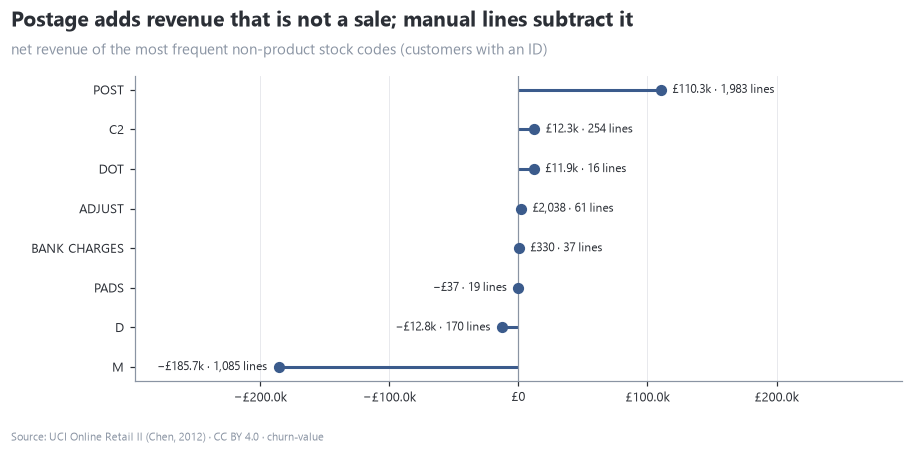

In [6]:
known = after_dupes[after_dupes["Customer ID"].notna()]
non_product = known[~known["StockCode"].str.match(PRODUCT_CODE_PATTERN)]
codes = (
    non_product.groupby("StockCode")
    .agg(lines=("revenue", "size"), net_revenue=("revenue", "sum"))
    .sort_values("lines", ascending=False)
)
top_codes = codes.head(8)
S["non_product_codes"] = int(len(codes))
S["non_product_top"] = top_codes.to_dict(orient="index")

fig, ax = plt.subplots(figsize=(9, 3.6))
order = top_codes.sort_values("net_revenue")
span = order["net_revenue"].abs().max() * 1.6
ax.hlines(order.index, 0, order["net_revenue"], color=NEUTRAL, lw=2)
ax.scatter(order["net_revenue"], order.index, color=NEUTRAL, s=40, zorder=3)
ax.axvline(0, color=MUTED, lw=0.8)
for code, row in order.iterrows():
    ha, dx = ("left", 0.03 * span) if row["net_revenue"] >= 0 else ("right", -0.03 * span)
    label = f"{style.gbp(row['net_revenue'])} · {int(row['lines']):,} lines"
    ax.text(row["net_revenue"] + dx, code, label, va="center", ha=ha, fontsize=8, color=INK)
ax.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax.grid(axis="y", visible=False)
ax.set_xlim(-span, span)
style.headline(
    fig,
    "Postage adds revenue that is not a sale; manual lines subtract it",
    "net revenue of the most frequent non-product stock codes (customers with an ID)",
)
style.add_source(fig)
save(fig, "non_product")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C5 · Returns and reversals</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">genuine returns stay, mis-keyed orders go</span></div>

Cancellation invoices (`C…`) are **not** dropped: a customer who returns goods is still a
customer. They are kept with negative revenue, flagged `is_return`, never counted as a purchase,
and they feed one feature (`return_rate`, stage 05).

One pattern is different: an order cancelled **the same day** for the same product, price and
quantity. That is a mis-keyed order and its reversal, not behaviour — the largest ones are
80,995 and 74,215 units bought and cancelled within minutes. Left in, each pair would add a
purchase day and phantom spend to the customer's history. The rule `same_day_reversal` removes
the pair, matched one-to-one; a return on a later day is never matched.

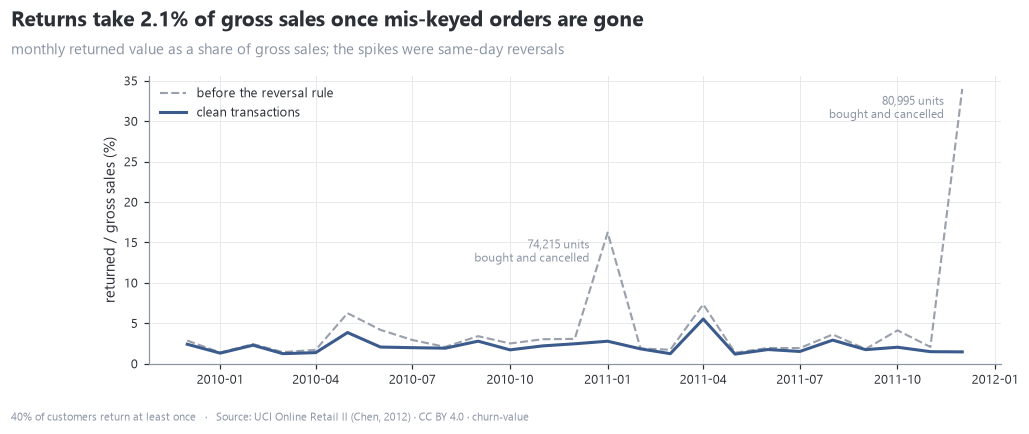

In [7]:
before, _ = apply_rules(raw.drop(columns="sheet"), CLEANING_RULES[:-1])
reversal = same_day_reversals(before)
reversed_lines = before.loc[reversal]
reversed_sales = reversed_lines[reversed_lines["Quantity"] > 0]
S["reversal_lines"] = int(reversal.sum())
S["reversal_customers"] = reversed_lines["Customer ID"].nunique()
S["reversal_gross_sales"] = (reversed_sales["Quantity"] * reversed_sales["Price"]).sum()
S["largest_reversals"] = (
    reversed_sales.assign(value=reversed_sales["Quantity"] * reversed_sales["Price"])
    .nlargest(2, "value")[["Customer ID", "Quantity", "value"]]
    .to_dict(orient="records")
)

tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
assert len(tx) == audit["rows_remaining"].iloc[-1]  # the pipeline's output = the audit's end


def monthly_return_share(frame, date_col, revenue):
    month = frame[date_col].dt.to_period("M").dt.to_timestamp()
    is_return = revenue < 0
    sales = revenue.where(~is_return, 0).groupby(month).sum()
    returns = -revenue.where(is_return, 0).groupby(month).sum()
    return returns / sales


with_reversals = monthly_return_share(before, "InvoiceDate", before["Quantity"] * before["Price"])
clean_share = monthly_return_share(tx, "date", tx["revenue"])
gross = tx.loc[~tx["is_return"], "revenue"].sum()
S["returned_share_of_gross"] = -tx.loc[tx["is_return"], "revenue"].sum() / gross
S["return_lines"] = int(tx["is_return"].sum())
S["customers_with_a_return"] = (
    tx.loc[tx["is_return"], "customer_id"].nunique() / tx["customer_id"].nunique()
)

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(
    with_reversals.index,
    with_reversals * 100,
    color=RETAINED,
    lw=1.4,
    ls="--",
    label="before the reversal rule",
)
ax.plot(clean_share.index, clean_share * 100, color=NEUTRAL, label="clean transactions")
for when, text in [
    ("2011-01-01", "74,215 units\nbought and cancelled"),
    ("2011-12-01", "80,995 units\nbought and cancelled"),
]:
    t = pd.Timestamp(when)
    ax.annotate(
        text,
        xy=(t, with_reversals[t] * 100),
        xytext=(-12, -4),
        textcoords="offset points",
        ha="right",
        va="top",
        fontsize=8,
        color=MUTED,
    )
ax.set_ylabel("returned / gross sales (%)")
ax.set_ylim(0, None)
ax.legend(loc="upper left")
style.headline(
    fig,
    f"Returns take {S['returned_share_of_gross']:.1%} of gross sales"
    " once mis-keyed orders are gone",
    "monthly returned value as a share of gross sales; the spikes were same-day reversals",
)
style.add_source(fig, f"{S['customers_with_a_return']:.0%} of customers return at least once")
save(fig, "returns")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">C6 · Final table</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">validated, and what it contains</span></div>

`clean_transactions` ends with the pandera schema `TRANSACTIONS_SCHEMA`: typed columns, product
codes only, and returns exactly the negative-revenue lines. Re-validating here costs nothing and
proves the file on disk is the one the schema describes.

In [8]:
TRANSACTIONS_SCHEMA.validate(tx)
recomputed = clean_transactions(raw.drop(columns="sheet"))
assert len(recomputed) == len(tx)
final = pd.Series(
    {
        "invoice lines": len(tx),
        "customers": tx["customer_id"].nunique(),
        "invoices": tx["invoice"].nunique(),
        "products": tx["stock_code"].nunique(),
        "countries": tx["country"].nunique(),
        "first day": tx["date"].min().date(),
        "last day": tx["date"].max().date(),
        "net revenue": style.gbp(tx["revenue"].sum()),
    }
)
S["final"] = final.to_dict()
S["kept_revenue_share"] = tx["revenue"].sum() / raw_revenue
display(final.rename("clean table").to_frame())

,clean table
invoice lines,791021
customers,5872
invoices,43314
products,4629
countries,41
first day,2009-12-01
last day,2011-12-09
net revenue,£16.36m


<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">02 → 03, 04</span></div>

**Produced** — `reports/results/02_summary.json` and the figures `02_rules`,
`02_missing_customer`, `02_non_product`, `02_returns`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>Two rules do nearly all the work: exact duplicates (mostly the December 2010 sheet overlap) and lines without a customer.</li><li>Missing customers are not random: 98.7 % are British guest lines, small and seasonal, so the results describe identifiable account customers, not all revenue.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>Eight ordered rules in <code>CLEANING_RULES</code>; three of them are guards that remove nothing on this file.</li><li>Same-day reversals (a mis-keyed order and its cancellation) are removed as a pair; returns on later days stay.</li><li>Returns stay in the table, flagged, with negative revenue; they are never purchases.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>03_eda</b> — purchase behaviour on the clean table: seasonality, cadence, concentration.</li><li><b>05_feature_engineering</b> — <code>return_rate</code> is built from the returns kept here.</li></ul></div>

In [9]:
S.write(RESULTS)

WindowsPath('reports/results/02_summary.json')